<a href="https://colab.research.google.com/github/CD-GRUPO3/TA047R-1C2025-GRUPO03/blob/main/TA047R_TP2_GRUPO03_CHPX_ENTREGA_N2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Grupo 3 - Trabajo Práctico 2

### Naive Bayes y Ensamble (Stacking)
**Integrantes:**
- ARIAS, Rafaela Pilar. 112272. rparias@fi.uba.ar.
- BARCALA ROCA, Ramiro. 112478. rbarcala@fi.uba.ar.
- LEMA, Mora. 111831. molema@fi.uba.ar.
- IENCO, Lara Eliana. 111921. lienco@fi.uba.ar.


---

Bibliografía:
- https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html

###Inicialización del entorno


In [1]:
# Importar las bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento de texto
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

In [2]:
!pip install nltk

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
#Cargamos los datos al Notebook

!gdown 1rbGVg-g0_H4UxviHdM3KFEHv5_DjJd-P
!gdown 19RRGPOcV-gQojb7G3wCtu1pY2Q4fQs_y

Downloading...
From: https://drive.google.com/uc?id=1rbGVg-g0_H4UxviHdM3KFEHv5_DjJd-P
To: /content/test.csv
100% 11.1M/11.1M [00:00<00:00, 51.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=19RRGPOcV-gQojb7G3wCtu1pY2Q4fQs_y
To: /content/train.csv
100% 72.2M/72.2M [00:01<00:00, 47.4MB/s]


In [4]:
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

print("Train - Columnas:", train_df.shape[1], "Filas:", train_df.shape[0])
print("Test - Columnas:", test_df.shape[1], "Filas:", test_df.shape[0])

print("\nPrimeras filas del train:")
display(train_df.head())

print("\nColumnas del train:")
print(train_df.columns)

print("\nDistribución de clases:")
print(train_df['sentimiento'].value_counts())


Train - Columnas: 3 Filas: 50000
Test - Columnas: 2 Filas: 8599

Primeras filas del train:


,ID,review_es,sentimiento
0,0,Uno de los otros críticos ha mencionado que de...,positivo
1,1,Una pequeña pequeña producción.La técnica de f...,positivo
2,2,Pensé que esta era una manera maravillosa de p...,positivo
3,3,"Básicamente, hay una familia donde un niño peq...",negativo
4,4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo



Columnas del train:
Index(['ID', 'review_es', 'sentimiento'], dtype='object')

Distribución de clases:
sentimiento
positivo    25000
negativo    25000
Name: count, dtype: int64


Observamos la cantidad de filas nulas en ambos conjuntos (train y test) y la cantidad de filas duplicadas

In [5]:
print("Cantidad total de valores NaN en el dataset train:", train_df.isnull().sum().sum())
print("Cantidad total de valores NaN en el dataset test:", test_df.isnull().sum().sum())

Cantidad total de valores NaN en el dataset train: 0
Cantidad total de valores NaN en el dataset test: 0


In [6]:
duplicadas_train = train_df.duplicated().sum()
print("Cantidad de filas duplicadas en el dataset train:", duplicadas_train)

duplicadas_test = test_df.duplicated().sum()
print("Cantidad de filas duplicadas en el dataset test:", duplicadas_test)

Cantidad de filas duplicadas en el dataset train: 0
Cantidad de filas duplicadas en el dataset test: 0


Al no haber duplicadas ni filas con NaN, no tuvimos que hacer nada al respecto.

###Preprocesamiento de los datos


Vamos a chequear si hay textos en otros idiomas que no sean español

In [7]:
!pip install langid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=0b6f689e20c3d323a64b9ac2b1b25796b82cca9915d679d817db41af5a862531
  Stored in directory: /root/.cache/pip/wheels/32/6a/b6/b7eb43a6ad55b139c15c5daa29f3707659cfa6944d3c696f5b
Successfully built langid


In [8]:
import langid

In [9]:
def detect_language(text):
    return langid.classify(str(text))[0]  # str() por si hay NaNs o números

train_df['language'] = train_df['review_es'].apply(detect_language)
test_df['language'] = test_df['review_es'].apply(detect_language)

Veamos cuántos idiomas hay y cuántas críticas por cada uno

In [10]:
conteo_idiomas_train = train_df['language'].value_counts()
print("Cantidad de idiomas en el dataset de entrenamiento: ", conteo_idiomas_train)
print(f"Cantidad de idiomas distintos: {train_df['language'].nunique()}")
conteo_idiomas_test = test_df['language'].value_counts()
print("\nCantidad de idiomas en el dataset de test: ", conteo_idiomas_test)

Cantidad de idiomas en el dataset de entrenamiento:  language
es    48179
en     1817
gl        2
pt        1
id        1
Name: count, dtype: int64
Cantidad de idiomas distintos: 5

Cantidad de idiomas en el dataset de test:  language
es    8597
ga       1
la       1
Name: count, dtype: int64


Nos quedamos sólo con las críticas en español

In [11]:
train_df = train_df[train_df['language'] == 'es'].copy()

In [12]:
print(train_df.shape)

(48179, 4)


###Limpieza y Tokenización


Veamos si las clases están balanceadas

In [13]:
train_df['sentimiento'].value_counts()

,count
sentimiento,
negativo,24131
positivo,24048


Separamos el dataset en entrenamiento 80% y test 20%

In [14]:
X = train_df['review_es']
y = train_df['sentimiento']

#Stratify para balancear la división
X_train_text, X_val_text, y_train, y_val = train_test_split(X,
                                                            y,
                                                            test_size = 0.2,
                                                            random_state = 42,
                                                            stratify = y
)

In [15]:
y_train.value_counts()

,count
sentimiento,
negativo,19305
positivo,19238


In [16]:
y_val.value_counts()

,count
sentimiento,
negativo,4826
positivo,4810


In [17]:
def clean_text(text):
    text = text.lower()

    text = re.sub(r'([.,!?;:])', r' \1 ', text)  #Añade espacio después de puntos y comas si no hay (para que no se junten palabras)
    text = re.sub(r'[^a-záéíóúüñ\s]', '', text) #Reemplaza todo lo que no sea letra o espacio
    text = re.sub(r'\s+[a-záéíóúüñ]\s+', ' ', text)  #Elimina letras sueltas entre espacios
    text = re.sub(r'\s+', ' ', text) #Y si se me juntaron varios espacios, los mergeo en uno
    return text.strip()


In [18]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 49.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [19]:
import spacy

#Cargar el modelo de español
nlp = spacy.load("es_core_news_sm")

#Función de lematización
def lemmatize_text(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc if token.lemma_.isalpha()])

Integramos clean_text y lemmatize_text en una función

In [20]:
def clean_and_lemmatize(text):
    cleaned = clean_text(text)
    lemmatized = lemmatize_text(cleaned)
    return lemmatized

In [21]:
#Defino la stoplist
stoplist = stopwords.words("spanish")
stoplist[:15]

['de',
 'la',
 'que',
 'el',
 'en',
 'y',
 'a',
 'los',
 'del',
 'se',
 'las',
 'por',
 'un',
 'para',
 'con']

In [22]:
def tokenizer(text):
    tokens = word_tokenize(text, language="spanish")
    return [
        t.lower()
        for t in tokens
        if t.isalpha()
        and t.lower() not in stoplist
        and 2 <= len(t) <= 20
        and len(set(t.lower())) > 1  #Descarta tokens con todas las letras iguales, ej: "aa", "aaa"
    ]

In [23]:
#Para chequear que estamos haciendo las cosas bien
ejemplo = X_train_text.sample(1).iloc[0]

print("Crítica original:")
print(ejemplo)
print("\nTexto limpio:")
print(clean_text(ejemplo))
print("\nTokens:")
print(tokenizer(clean_text(ejemplo)))

Crítica original:
Los críticos han comenzado a llamarlo el Ganador del Oscar, comprensiblemente. Lo que después de Halle Berry lo ganó para Monsters Ball y luego irá directamente a la catwoman diabólica. Hilary Swank Triumphs en niños no llora y lo sigue con el núcleo. Jamie Foxx toma un piloto como piloto en el Stealth opaco después de recoger un Gong para Ray. Ahora, parece que Hollywood Starlet Charlize Theron se basa en su "monstruo" Oscar con este de los peores espectáculos de ciencia ficción jamás hechos. La película pierde su interés de la audiencia después de un mero 20 minutos, lo que vale la pena quedarse es el hecho Que a pesar de que la película, la basura, Charlize, Theron, todavía es una actriz excepcional que está haciendo claramente lo mejor de una premisa cruda y ridícula. No solo el flujo no solo es, en última instancia, pero para un movimiento de acción también es realmente muy aburrido. Solo atraerá realmente a los fanáticos de los cómics y los adolescentes de Horne

####Vectorización

In [24]:
import warnings
warnings.filterwarnings("ignore", message="The parameter 'token_pattern' will not be used*")

from sklearn.feature_extraction.text import TfidfVectorizer

tfid_vectorizer = TfidfVectorizer(
    preprocessor = clean_and_lemmatize, #Aplicamos limpieza + lematización
    tokenizer = tokenizer,
    min_df = 10,
    max_df = 0.8,
    ngram_range = (1, 3) # unigramas, bigramas, trigramas
)

X_train_tfid = tfid_vectorizer.fit_transform(X_train_text)
X_val_tfid = tfid_vectorizer.transform(X_val_text)

print("Cantidad de textos en entrenamiento:", X_train_tfid.shape[0])
print("Cantidad de palabras distintas en entrenamiento:", X_train_tfid.shape[1])
print("\n")

contador_palabras = np.array(X_train_tfid.sum(axis = 0)).flatten() #Sumamos frecuencias por palabra
palabras = tfid_vectorizer.get_feature_names_out() #Obtenemos las palabras del vocabulario

#Armamos un DataFrame ordenado
freq_df = pd.DataFrame({'palabra': palabras, 'frecuencia': contador_palabras})
freq_df = freq_df.sort_values(by = 'frecuencia', ascending = False)

#Mostramos las 20 más frecuentes
display(freq_df.head(20))

Cantidad de textos en entrenamiento: 38543
Cantidad de palabras distintas en entrenamiento: 74157




,palabra,frecuencia
27047,haber,1166.218317
66659,tener,915.281869
70834,ver,902.643719
50265,poder,871.594053
28496,hacer,850.561481
63072,si,623.348100
30173,historia,570.469976
64413,solo,550.967117
2153,alguno,548.702375
47552,película ser,530.062093


In [26]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    preprocessor = clean_and_lemmatize,
    tokenizer = tokenizer,
    stop_words = stoplist,
    min_df = 10,
    max_df = 0.8,
    ngram_range = (1, 3) #unigramas, bigramas, trigramas
)

X_train_count = count_vectorizer.fit_transform(X_train_text)
X_val_count = count_vectorizer.transform(X_val_text)

print("Cantidad de textos en entrenamiento:", X_train_tfid.shape[0])
print("Cantidad de palabras distintas en entrenamiento:", X_train_tfid.shape[1])
print("\n")

contador_palabras = np.array(X_train_count.sum(axis = 0)).flatten() #Sumamos frecuencias por palabra
palabras = count_vectorizer.get_feature_names_out() #Obtenemos las palabras del vocabulario

#Armamos un DataFrame ordenado
freq_df = pd.DataFrame({'palabra': palabras, 'frecuencia': contador_palabras})
freq_df = freq_df.sort_values(by = 'frecuencia', ascending = False)

#Mostramos las 20 más frecuentes
display(freq_df.head(20))

Cantidad de textos en entrenamiento: 38543
Cantidad de palabras distintas en entrenamiento: 74157




,palabra,frecuencia
27047,haber,73953
66659,tener,52876
50265,poder,48261
70834,ver,48154
28496,hacer,47100
63072,si,27993
64413,solo,24249
2153,alguno,23587
30173,historia,22378
71975,vez,20889


##Naive bayes

Para entrenar el modelo Naive Bayes compararemos tres enfoques de clasificación, combinando distintas estrategias de representación del texto (TF-IDF y con CountVectorizer, considerando en ambos unigramas, bigramas y trigramas) y modelos (Naive Bayes y un clasificador Dummy). Con esta información, evaluaremos que combinación ofrece mejor rendimiento en términos de la métrica F1 macro.

Primero convertimos las etiquetas categóricas a valores numéricos utilizando LabelEncoder, dado que el modelo no acepta strings como etiquetas.

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

**Primer enfoque: TF-IDF + Naive Bayes**


Evaluamos el modelo Naive Bayes vectorizando el texto con TF-IDF y usando validación cruzada con 10 folds. Utilizamos la métrica F1 macro para tener en cuenta el rendimiento balanceado entre clases.

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

param_grid = {
    'alpha': [0.5, 1.0, 1.5, 2.0],
    'fit_prior': [True, False]
}

grid_search_nb = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv = 10,
    scoring = 'f1_macro',
    n_jobs = 1
)

grid_search_nb.fit(X_train_tfid, y_train_encoded)

print("Mejores hiperparámetros encontrados:")
print(grid_search_nb.best_params_)

#Guardamos el mejor clasificador
clf_tfidf = grid_search_nb.best_estimator_

Mejores hiperparámetros encontrados:
{'alpha': 0.5, 'fit_prior': True}


In [29]:
from sklearn.model_selection import cross_val_score
#Cross-validation
scores_cv_nb = cross_val_score(clf_tfidf, X_train_tfid, y_train_encoded, cv = 10, scoring = 'f1_macro')
print("F1 macro promedio (CV):", round(scores_cv_nb.mean(), 4))
print("Desviación estándar:", round(scores_cv_nb.std(), 4))

F1 macro promedio (CV): 0.8816
Desviación estándar: 0.0035


**Segundo enfoque: TF-IDF + DummyClassifier**


Luego, entrenamos un clasificador Dummy que predice al azar según la distribución de clases.
Este modelo sirve como referencia mínima para comparar el rendimiento del modelo real.

In [30]:
from sklearn.dummy import DummyClassifier

clf_dummy = DummyClassifier(strategy = "stratified")
scores_dummy_cv = cross_val_score(clf_dummy, X_train_tfid, y_train_encoded, cv = 10, scoring = 'f1_macro')

print("Dummy F1 macro promedio:", round(scores_dummy_cv.mean(), 4))

Dummy F1 macro promedio: 0.5047


**Tercer enfoque: CountVectorizer + Naive Bayes**

Para esta alternativa, entrenamos el modelo Naive Bayes utilizando como entrada la representación del texto generada con CountVectorizer. Para ello, utilizamos validación cruzada con 10 folds y la métrica F1 macro.

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

param_grid = {
    'alpha': [0.5, 1.0, 1.5, 2.0],
    'fit_prior': [True, False]
}

grid_search_cv = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv = 10,
    scoring = 'f1_macro',
    n_jobs = 1
)

#Entrenamos usando los datos vectorizados con CountVectorizer
grid_search_cv.fit(X_train_count, y_train_encoded)

#Mostramos resultados
print("Mejores hiperparámetros (CountVectorizer):")
print(grid_search_cv.best_params_)

#Guardamos el mejor modelo
clf_cv = grid_search_cv.best_estimator_

Mejores hiperparámetros (CountVectorizer):
{'alpha': 0.5, 'fit_prior': True}


In [32]:
scores_cv_count = cross_val_score(clf_cv, X_train_tfid, y_train_encoded, cv = 10, scoring = 'f1_macro')
print("F1 macro promedio (CV):", round(scores_cv_count.mean(), 4))

F1 macro promedio (CV): 0.8816


Comparemos el desempeño promedio de F1 macro de las tres estrategias analizadas:

In [33]:
pd.Series({
    'Naive Bayes con TF-IDF': round(scores_cv_nb.mean(), 4),
    'Naive Bayes con CountVectorizer': round(scores_cv_count.mean(), 4),
    'Dummy Classifier': round(scores_dummy_cv.mean(), 4)
})

,0
Naive Bayes con TF-IDF,0.8816
Naive Bayes con CountVectorizer,0.8816
Dummy Classifier,0.5047


Notamos que el F1 macro promedio es igual usando CountVectorizer y TF-IDF. Utilicemos el coseno de similitud para ver el resultado (si está cerca de 1.0 los vectores son casi iguales)

In [34]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(X_train_tfid[:1], X_train_count[:1])
print("Cosine similarity entre vectores TF-IDF y Count:", similarity[0][0])

Cosine similarity entre vectores TF-IDF y Count: 0.8995484337319692


Esto nos dice que están generando representaciones muy parecidas y la verdad tiene sentido ya que que el modelo es el mismo (MultinomialNB), el espacio de búsqueda es igual (alpha, fit_prior) y usamos los mismos parámetros para ambos vectorizadores (como ngram_range, min_df, max_df). Optaremos por implementar la variante con TF-IDF porque no solo cuenta las palabras, sino que les da más importancia a las que son realmente útiles para distinguir los textos.


Para el reporte final:
Invertimos la codificación para interpretar las predicciones con etiquetas originales.

In [35]:
#Transformarmos el texto de validación
X_val_vect = tfid_vectorizer.transform(X_val_text)

#Predecimos etiquetas codificadas en validación
y_pred_encoded = clf_tfidf.predict(X_val_vect)

In [36]:
y_val_text = le.inverse_transform(y_val_encoded)
y_pred_text = le.inverse_transform(y_pred_encoded)

Implementamos una función para poder observar las métricas en el conjunto train y test.

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluar(y_true, y_pred, nombre):
    print(f"--- {nombre} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, pos_label='positivo'):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, pos_label='positivo'):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, pos_label='positivo'):.4f}")
    print()

Reporte de clasificación (Validación):
              precision    recall  f1-score   support

    negativo       0.89      0.86      0.88      4826
    positivo       0.87      0.89      0.88      4810

    accuracy                           0.88      9636
   macro avg       0.88      0.88      0.88      9636
weighted avg       0.88      0.88      0.88      9636

--- Naive Bayes - Validación ---
Accuracy : 0.8784
Precision: 0.8672
Recall   : 0.8931
F1 Score : 0.8800



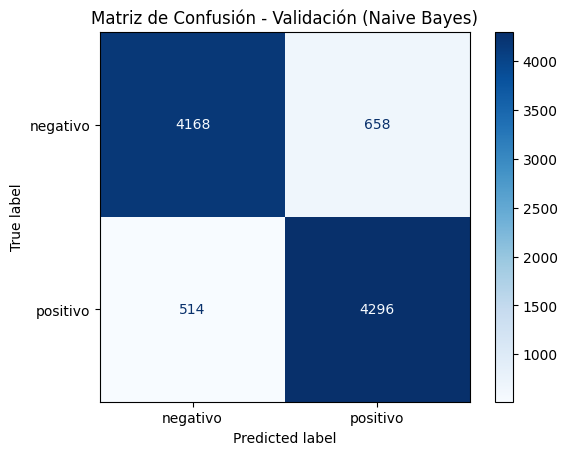



--- Naive Bayes - Train ---
Accuracy : 0.9242
Precision: 0.9149
Recall   : 0.9351
F1 Score : 0.9249



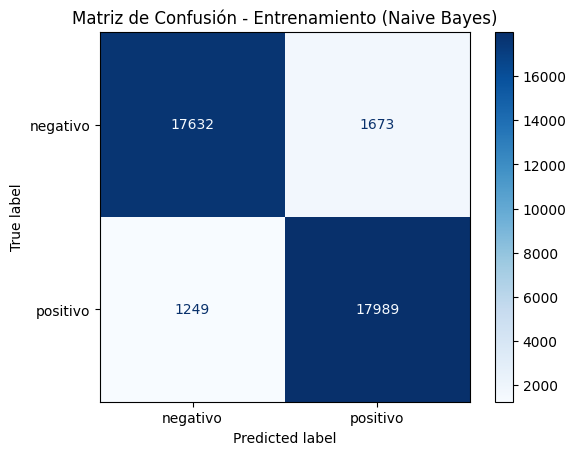

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

print("Reporte de clasificación (Validación):")
print(classification_report(y_val_text, y_pred_text))

evaluar(y_val_text, y_pred_text, "Naive Bayes - Validación")

# Matriz de confusión - Validación
cm_val = confusion_matrix(y_val_text, y_pred_text, labels=le.classes_)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=le.classes_)
disp_val.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Validación (Naive Bayes)")
plt.show()

print("\n")

y_train_pred_encoded = clf_tfidf.predict(X_train_tfid)
y_train_text = le.inverse_transform(y_train_encoded)
y_train_pred_text = le.inverse_transform(y_train_pred_encoded)

evaluar(y_train_text, y_train_pred_text, "Naive Bayes - Train")
# Matriz de confusión - Entrenamiento
cm_train = confusion_matrix(y_train_text, y_train_pred_text, labels=le.classes_)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=le.classes_)
disp_train.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Entrenamiento (Naive Bayes)")
plt.show()

In [39]:
#Submission para Kaggle
X_test_vect = tfid_vectorizer.transform(test_df["review_es"])
y_test_pred_encoded = clf_tfidf.predict(X_test_vect)
y_test_pred_text = le.inverse_transform(y_test_pred_encoded)

submission = pd.DataFrame({
    "ID": test_df["ID"],
    "sentimiento": y_test_pred_text
})
submission.to_csv("submission_nb.csv", index=False)

In [40]:
#Con esto lo descargamos
from google.colab import files
files.download('submission_nb.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Ensamble híbrido: Stacking

Para realizar el ensamble optamos por el modelo Stacking, que combina las predicciones de múltiples clasificadores para mejorar el rendimiento general. En nuestro caso, los modelos base seleccionados fueron Regresión Logística, Random Forest y Naive Bayes, debido a que representan enfoques diversos: lineal, no lineal y probabilístico, respectivamente.

Como meta-modelo, elegimos el clasificador XGBoost, conocido por su alto rendimiento en tareas de clasificación, ya que puede aprender a combinar de manera óptima las predicciones de los modelos base, corrigiendo sus errores y mejorando la capacidad de generalización del conjunto.

Antes de entrenar el modelo de stacking, convertimos las etiquetas de texto de la variable objetivo a valores numéricos con LabelEncoder. Esto es necesario porque algunos clasificadores del ensemble no admiten directamente etiquetas categóricas en forma de texto.

In [46]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_stack = le.fit_transform(y_train)
y_val_stack = le.transform(y_val)

In [48]:
!pip install xgboost

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import classification_report
import pandas as pd

#Modelos base si hacemos el tdif vectorizer
base_models = [
    ('lr', LogisticRegression(max_iter=300, C=1.0, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=60, max_depth=6, random_state=42)),
    ('nb', MultinomialNB()),
]

# Meta-modelo
meta_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

#Ensemble con stacking
stacking_model = StackingClassifier(
    estimators = base_models,
    final_estimator = meta_model,
    passthrough = True,
    cv = 4,
    verbose = 2,
    n_jobs = -1
)

Seleccionamos los límites de búsqueda de hiperparametros.

In [50]:
param_distributions = {
    'lr__C': uniform(0.1, 0.5),

    'rf__n_estimators': [100, 125, 150],
    'rf__max_depth': [5, 7, 9],

    'final_estimator__learning_rate': uniform(0.07, 0.1),
    'final_estimator__max_depth': [3, 4],
    'final_estimator__n_estimators': [80, 100, 120],
    'final_estimator__subsample': uniform(0.6, 0.3),
    'final_estimator__colsample_bytree': uniform(0.6, 0.2)
}

Buscamos los mejores hiperparámetros utilizando RandomizedSearchCV con 3 folds y entrenamos el modelo.

In [51]:
#Búsqueda de hiperparámetros con RandomizedSearchCV
stacking_search = RandomizedSearchCV(
    estimator = stacking_model,
    param_distributions = param_distributions,
    n_iter = 15,
    scoring = 'f1',
    cv = 3,
    verbose = 2,
    random_state = 42,
    n_jobs = -1
)

#Entrenamiento
stacking_search.fit(X_train_tfid, y_train_stack)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=3,
                   estimator=StackingClassifier(cv=4,
                                                estimators=[('lr',
                                                             LogisticRegression(max_iter=300,
                                                                                random_state=42)),
                                                            ('rf',
                                                             RandomForestClassifier(max_depth=6,
                                                                                    n_estimators=60,
                                                                                    random_state=42)),
                                                            ('nb',
                                                             MultinomialNB())],
                                                final_estimator=XGBClassifier(base_score=None,
                                                                              booster=None,
                                                                              callbacks=None,
                                                                              colsample_bylevel=None,
                                                                              colsample_bynode=None,
                                                                              colsam...
                                        'final_estimator__max_depth': [3, 4],
                                        'final_estimator__n_estimators': [80,
                                                                          100,
                                                                          120],
                                        'final_estimator__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f7a2187c810>,
                                        'lr__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f7a2187d050>,
                                        'rf__max_depth': [5, 7, 9],
                                        'rf__n_estimators': [100, 125, 150]},
                   random_state=42, scoring='f1', verbose=2)

In [52]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(stacking_model, X_train_tfid, y_train_stack, scoring='f1', n_jobs=-1)
print(f"F1 promedio en validación cruzada: {scores.mean():.4f}")

F1 promedio en validación cruzada: 0.8970


In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluar_stack(y_true, y_pred, nombre):
    print(f"--- {nombre} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, pos_label=1):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, pos_label=1):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, pos_label=1):.4f}")
    print()

Veamos las distintas metricas:


Mejores hiperparámetros: {'final_estimator__colsample_bytree': np.float64(0.6918497783931734), 'final_estimator__learning_rate': np.float64(0.1033708611139022), 'final_estimator__max_depth': 4, 'final_estimator__n_estimators': 120, 'final_estimator__subsample': np.float64(0.6061753482887408), 'lr__C': np.float64(0.5849549260809972), 'rf__max_depth': 7, 'rf__n_estimators': 125}
Mejor score F1 (cross-val): 0.8946964563023244
--- Stacking - Entrenamiento ---
Accuracy : 0.9438
Precision: 0.9408
Recall   : 0.9471
F1 Score : 0.9439

              precision    recall  f1-score   support

    negativo       0.95      0.94      0.94     19305
    positivo       0.94      0.95      0.94     19238

    accuracy                           0.94     38543
   macro avg       0.94      0.94      0.94     38543
weighted avg       0.94      0.94      0.94     38543



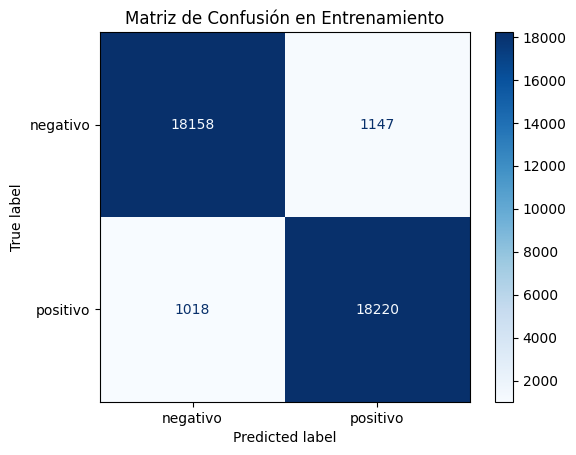



--- Stacking - Validación ---
Accuracy : 0.8958
Precision: 0.8903
Recall   : 0.9025
F1 Score : 0.8963

              precision    recall  f1-score   support

    negativo       0.90      0.89      0.90      4826
    positivo       0.89      0.90      0.90      4810

    accuracy                           0.90      9636
   macro avg       0.90      0.90      0.90      9636
weighted avg       0.90      0.90      0.90      9636



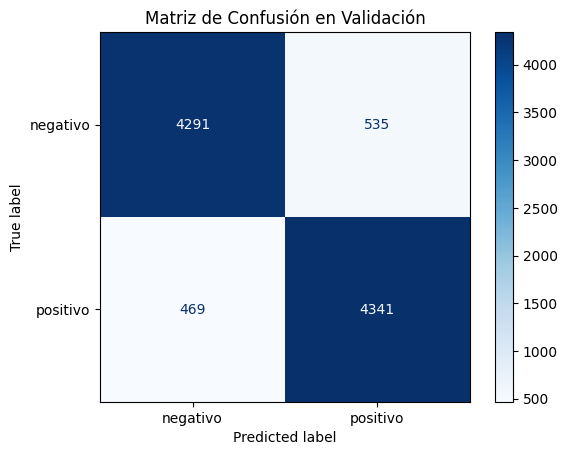

In [54]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

print("\nMejores hiperparámetros:", stacking_search.best_params_)
print("Mejor score F1 (cross-val):", stacking_search.best_score_)

#Predicciones
y_train_pred = stacking_search.predict(X_train_tfid)
y_val_pred = stacking_search.predict(X_val_tfid)

#Decodificar etiquetas y predicciones a strings
y_train_real = le.inverse_transform(y_train_stack)
y_train_pred_real = le.inverse_transform(y_train_pred)

y_val_real = le.inverse_transform(y_val_stack)
y_val_pred_real = le.inverse_transform(y_val_pred)

# === MÉTRICAS SOBRE TRAIN ===
evaluar_stack(y_train_stack, y_train_pred, "Stacking - Entrenamiento")
print(classification_report(y_train_real, y_train_pred_real, target_names=le.classes_))

cm_train = confusion_matrix(y_train_real, y_train_pred_real)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=le.classes_)
disp_train.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión en Entrenamiento")
plt.show()

print("\n")

# === MÉTRICAS SOBRE VALIDACIÓN ===
evaluar_stack(y_val_stack, y_val_pred, "Stacking - Validación")
print(classification_report(y_val_real, y_val_pred_real, target_names=le.classes_))

cm_val = confusion_matrix(y_val_real, y_val_pred_real)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=le.classes_)
disp_val.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión en Validación")
plt.show()


Realizamos las predicciones para Kaggle y descargamos el archivo.

In [55]:
X_test_tfid = tfid_vectorizer.transform(test_df["review_es"])
# Predicción final sobre test
y_test_pred = stacking_search.predict(X_test_tfid)
y_test_pred_labels = le.inverse_transform(y_test_pred)

# Guardar submission
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "sentimiento": y_test_pred_labels
})
submission.to_csv("submission_stacking.csv", index=False)

In [56]:
from google.colab import files
files.download("submission_stacking.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>